# Darkness OR And GLM Comparison

This notebook is a bridge between the two existing analyses:

- the pooled case-control hour odds-ratio results from [Reprocess OR Confirmation.ipynb](./Reprocess%20OR%20Confirmation.ipynb)
- the time-series GLM framework from [Darkness GLM Models.ipynb](./Darkness%20GLM%20Models.ipynb)

## What this notebook is for

It keeps two different goals separate:

1. **Direct cross-comparison with the OR design**
   - uses the same cleaned 37 sensors
   - uses the same mixed case hours as the OR notebook: `5, 6, 17, 18, 19, 20`
   - fits the same four-model GLM ladder on that sample

2. **Expanded mixed-hours sensitivity analysis**
   - keeps the same 37 sensors and same GLM structure
   - widens the sample to all mixed hours in the cleaned data: `4, 5, 6, 7, 17, 18, 19, 20, 21`
   - tests whether the main findings change when more mixed-hour data are included

## How to read the notebook

- The **OR section** is the closest match to the original case-control design.
- The **comparison GLM section** is the fairest GLM comparison with the OR results.
- The **expanded GLM section** is a robustness analysis, not a replacement for the OR-comparable model.

A key point throughout is that **OR and GLM coefficients are not on the same scale**, so the comparison should focus on:

- direction of effect
- which mode has the clearer darkness signal
- whether the same substantive conclusions survive across methods and samples


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tools.sm_exceptions import ValueWarning
from IPython.display import display

warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=ValueWarning)
plt.style.use('seaborn-v0_8-whitegrid')


def find_notebook_dir() -> Path:
    cwd = Path.cwd()
    candidates = [
        cwd,
        cwd / 'main' / 'Karan - Notebooks and analysis',
    ]
    for candidate in candidates:
        if (candidate / 'Processed Data' / 'all_sensor_data_with_locations_and_clusters.csv').exists():
            return candidate

    for parent in [cwd, *cwd.parents]:
        candidate = parent / 'main' / 'Karan - Notebooks and analysis'
        if (candidate / 'Processed Data' / 'all_sensor_data_with_locations_and_clusters.csv').exists():
            return candidate

    raise FileNotFoundError('Could not locate the notebook data folder.')


NOTEBOOK_DIR = find_notebook_dir()
REPO_DIR = NOTEBOOK_DIR.parents[1]
PROCESSED_DATA_DIR = NOTEBOOK_DIR / 'Processed Data'

BASE_PANEL_PATH = PROCESSED_DATA_DIR / 'all_sensor_data_with_locations_and_clusters.csv'
WEATHER_PATH = REPO_DIR / 'data' / 'weather' / 'weather_2024_almondsbury_clean.csv'
RAIN_PATH = REPO_DIR / 'data' / 'weather' / 'rain_2024_almondsbury_clean.csv'
CCTV_PATH = PROCESSED_DATA_DIR / 'sensor_cctv_within_300m_clean37.csv'
SAFETY_PATH = PROCESSED_DATA_DIR / 'sensor_ward_safety_after_dark_2024_clean37.csv'
OR_LONG_PATH = PROCESSED_DATA_DIR / 'case_control_hour_or_pooled_ped_cyc_long.csv'

print('NOTEBOOK_DIR =', NOTEBOOK_DIR)
print('BASE_PANEL   =', BASE_PANEL_PATH)
print('OR_LONG      =', OR_LONG_PATH)
print('WEATHER      =', WEATHER_PATH)
print('RAIN         =', RAIN_PATH)
print('CCTV         =', CCTV_PATH)
print('SAFETY       =', SAFETY_PATH)


NOTEBOOK_DIR = /Users/karandama/Documents/School stuff/Uni Shit/Y2/MDM2/Group-3-MDM/main/Karan - Notebooks and analysis
BASE_PANEL   = /Users/karandama/Documents/School stuff/Uni Shit/Y2/MDM2/Group-3-MDM/main/Karan - Notebooks and analysis/Processed Data/all_sensor_data_with_locations_and_clusters.csv
OR_LONG      = /Users/karandama/Documents/School stuff/Uni Shit/Y2/MDM2/Group-3-MDM/main/Karan - Notebooks and analysis/Processed Data/case_control_hour_or_pooled_ped_cyc_long.csv
WEATHER      = /Users/karandama/Documents/School stuff/Uni Shit/Y2/MDM2/Group-3-MDM/data/weather/weather_2024_almondsbury_clean.csv
RAIN         = /Users/karandama/Documents/School stuff/Uni Shit/Y2/MDM2/Group-3-MDM/data/weather/rain_2024_almondsbury_clean.csv
CCTV         = /Users/karandama/Documents/School stuff/Uni Shit/Y2/MDM2/Group-3-MDM/main/Karan - Notebooks and analysis/Processed Data/sensor_cctv_within_300m_clean37.csv
SAFETY       = /Users/karandama/Documents/School stuff/Uni Shit/Y2/MDM2/Group-3-MDM/m

## OR Results From The Case-Control Notebook

This section loads the pooled OR output that was already created in the OR notebook.

That design compares:

- **case hours** that are mixed between daylight and darkness over the year
- against fixed **dark control hours** and **daylight control hours**
- matched within `SensorNumber` and `day`

The pooled OR file contains one OR for each:

- mode
- case hour
- control hour

To make that output easier to compare with the GLM, this notebook summarises the ORs across control hours using medians and ranges by case hour.


OR rows: 120


,Mode,case_hour,case_hour_label,median_R_odds,min_R_odds,max_R_odds,median_log_R_odds,paired_rows,n_control_hours
0,Cyclists,5,05:00-05:59,1.378926,0.923396,1.839482,0.297830,13542,10
1,Cyclists,6,06:00-06:59,2.209877,1.440841,3.009230,0.772356,13542,10
2,Cyclists,17,17:00-17:59,1.047875,0.755536,2.747891,0.034747,13542,10
3,Cyclists,18,18:00-18:59,1.054381,0.723053,1.693442,0.036420,13542,10
4,Cyclists,19,19:00-19:59,1.120945,0.742207,1.601824,0.090369,13542,10
5,Cyclists,20,20:00-20:59,1.123257,0.798795,1.550007,0.098946,13542,10
6,Pedestrians,5,05:00-05:59,2.277745,1.647960,3.058849,0.820575,13542,10
7,Pedestrians,6,06:00-06:59,3.064802,2.126595,4.007390,1.115379,13542,10
8,Pedestrians,17,17:00-17:59,1.255050,0.937821,2.091817,0.223947,13542,10
9,Pedestrians,18,18:00-18:59,1.261906,0.926039,1.682180,0.229041,13542,10


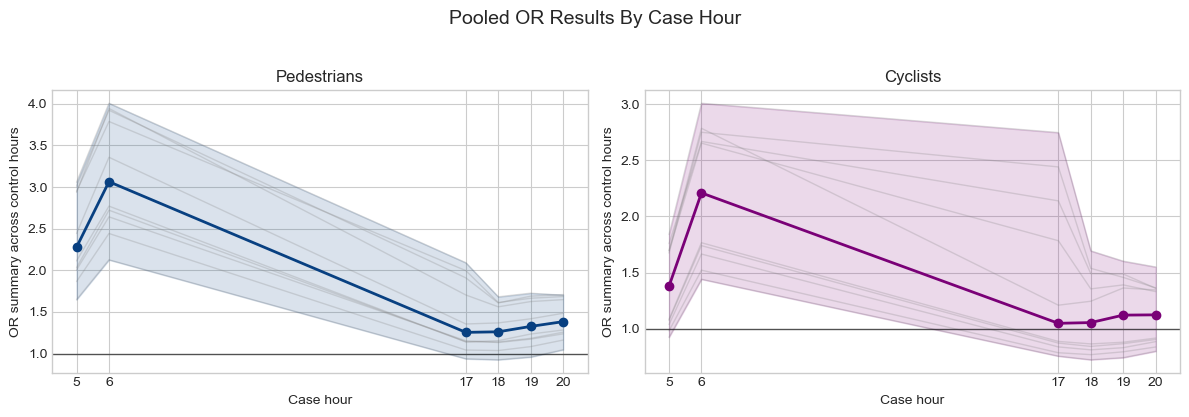

In [2]:
or_long = pd.read_csv(OR_LONG_PATH)
or_long['log_R_odds'] = np.log(or_long['R_odds'])

or_summary = (
    or_long.groupby(['Mode', 'case_hour', 'case_hour_label'], as_index=False)
    .agg(
        median_R_odds=('R_odds', 'median'),
        min_R_odds=('R_odds', 'min'),
        max_R_odds=('R_odds', 'max'),
        median_log_R_odds=('log_R_odds', 'median'),
        paired_rows=('paired_rows', 'first'),
        n_control_hours=('R_odds', 'size'),
    )
    .sort_values(['Mode', 'case_hour'])
    .reset_index(drop=True)
)

print('OR rows:', len(or_long))
display(or_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
mode_order = ['Pedestrians', 'Cyclists']
colors = {'Pedestrians': '#084081', 'Cyclists': '#7a0177'}

for ax, mode_name in zip(axes, mode_order):
    sub = or_long[or_long['Mode'] == mode_name].copy()
    summ = or_summary[or_summary['Mode'] == mode_name].copy()

    for control_hour, control_group in sub.groupby('control_hour_label'):
        ax.plot(
            control_group['case_hour'],
            control_group['R_odds'],
            color='grey',
            alpha=0.25,
            linewidth=1,
        )
    ax.plot(
        summ['case_hour'],
        summ['median_R_odds'],
        marker='o',
        color=colors[mode_name],
        linewidth=2,
    )
    ax.fill_between(
        summ['case_hour'],
        summ['min_R_odds'],
        summ['max_R_odds'],
        color=colors[mode_name],
        alpha=0.15,
    )
    ax.axhline(1.0, color='black', linewidth=1, alpha=0.6)
    ax.set_xticks(sorted(summ['case_hour'].unique()))
    ax.set_title(mode_name)
    ax.set_xlabel('Case hour')
    ax.set_ylabel('OR summary across control hours')

fig.suptitle('Pooled OR Results By Case Hour', y=1.03, fontsize=14)
plt.tight_layout()
plt.show()


## OR Interpretation

The OR plot should be read as a **pattern comparison across case hours**, not as a percentage change in counts.

A value of **1** means no difference between the light and dark versions of the case hour once compared with the chosen control hours. Values **above 1** mean the daylight version of the case hour is more heavily represented than the darkness version, which is consistent with darkness reducing activity.

Three points stand out.

- **Pedestrians have the clearer OR signal.** The median OR is above `1` at every case hour and is especially large at `05:00` and `06:00` (`2.28` and `3.06`). That means the early-morning mixed hours show the strongest daylight-versus-darkness contrast for walking.
- **Cyclists also show a morning signal, but it is weaker and less consistent.** The cyclist median OR is strongest at `06:00` (`2.21`) and modest at `05:00` (`1.38`), but it is close to `1` across the evening case hours (`17:00` to `20:00`).
- **The range across control hours matters.** The grey lines show that the exact OR changes depending on which control hour is used. That is one reason the GLM is a useful complement: it estimates the darkness effect after controlling for time structure directly rather than relying on a fixed set of control hours.

So the OR section already points to the core story: walking has a stronger and more stable darkness signal than cycling, and the contrast is sharpest in the morning transition hours.


## Build The GLM Analysis Panel

This reproduces the cleaned 37-sensor GLM dataset used in the existing darkness notebook.

The important features are:

- same cleaned sensor set as the OR workflow
- same hourly weather and rain data
- same CCTV and safety context variables
- same lag structure (`lag1`, `lag24`)
- same exclusion of `twilight`

The only thing that changes later is the **hour set** used for estimation.


In [3]:
panel = pd.read_csv(BASE_PANEL_PATH)
panel['datetime'] = pd.to_datetime(panel['date'], utc=True, errors='coerce')

weather = pd.read_csv(WEATHER_PATH)
weather['datetime'] = pd.to_datetime(weather['datetime'], utc=True, errors='coerce')

rain = pd.read_csv(RAIN_PATH)
rain['datetime'] = pd.to_datetime(rain['datetime'], utc=True, errors='coerce')

cctv = pd.read_csv(CCTV_PATH)[['SensorNumber', 'cctv_300m']].drop_duplicates('SensorNumber')
safety = pd.read_csv(SAFETY_PATH)[['SensorNumber', 'safety_after_dark_pct']].drop_duplicates('SensorNumber')

panel = panel.merge(weather, on='datetime', how='left')
panel = panel.merge(rain, on='datetime', how='left')
panel = panel.merge(cctv, on='SensorNumber', how='left')
panel = panel.merge(safety, on='SensorNumber', how='left')

panel['rain_mm'] = panel['rain_mm'].fillna(0)
panel['hour'] = panel['datetime'].dt.hour.astype(int)
panel['dow'] = panel['datetime'].dt.dayofweek.astype(int)
panel['month'] = panel['datetime'].dt.month.astype(int)
panel['day'] = panel['datetime'].dt.normalize()

panel = panel.sort_values(['SensorNumber', 'datetime']).reset_index(drop=True)
panel['ped_lag1'] = panel.groupby('SensorNumber')['ped'].shift(1)
panel['ped_lag24'] = panel.groupby('SensorNumber')['ped'].shift(24)
panel['cyc_lag1'] = panel.groupby('SensorNumber')['cyc'].shift(1)
panel['cyc_lag24'] = panel.groupby('SensorNumber')['cyc'].shift(24)

hour_mix = panel.groupby('hour')['Dark'].agg(['min', 'max', 'mean']).sort_index()
all_mixed_hours = hour_mix.index[(hour_mix['min'] == 0) & (hour_mix['max'] == 1)].tolist()
comparison_hours = [5, 6, 17, 18, 19, 20]
expanded_hours = all_mixed_hours

print('All mixed hours     :', expanded_hours)
print('Comparison hours    :', comparison_hours)
print('Expanded hours      :', expanded_hours)
display(hour_mix)


All mixed hours     : [4, 5, 6, 7, 17, 18, 19, 20, 21]
Comparison hours    : [5, 6, 17, 18, 19, 20]
Expanded hours      : [4, 5, 6, 7, 17, 18, 19, 20, 21]


,min,max,mean
hour,,,
0,1,1,1.000000
1,1,1,1.000000
2,1,1,1.000000
3,1,1,1.000000
4,0,1,0.745902
5,0,1,0.576503
6,0,1,0.404593
7,0,1,0.224044
8,0,0,0.000000


## Helper Functions

The same four-model ladder is fitted on both hour sets:

1. **Model 1:** main pooled darkness model
2. **Model 2:** darkness-by-cluster heterogeneity
3. **Model 3:** darkness-by-CCTV heterogeneity
4. **Model 4:** darkness-by-safety heterogeneity

The main pooled comparison with OR should always focus first on **Model 1**.


In [4]:
def coef_percent_change(beta):
    return 100 * (np.exp(beta) - 1)


def fit_nb_glm(data, outcome, rhs, required_cols, label):
    cols = list(dict.fromkeys(required_cols + [outcome, 'SensorNumber']))
    model_df = data[cols].dropna().copy()
    formula = f'{outcome} ~ {rhs}'

    model = smf.glm(
        formula=formula,
        data=model_df,
        family=sm.families.NegativeBinomial(),
    )
    result = model.fit(
        cov_type='cluster',
        cov_kwds={'groups': model_df['SensorNumber']},
    )

    info = {
        'label': label,
        'outcome': outcome,
        'n_rows': len(model_df),
        'n_sensors': model_df['SensorNumber'].nunique(),
        'dispersion': float((result.pearson_chi2 / result.df_resid) if result.df_resid else np.nan),
        'formula': formula,
    }
    return result, model_df, info


def run_model_ladder(panel_df, sample_name):
    sensor_context = (
        panel_df[['SensorNumber', 'Cluster', 'cctv_300m', 'safety_after_dark_pct']]
        .drop_duplicates('SensorNumber')
        .sort_values('SensorNumber')
        .reset_index(drop=True)
    )

    cctv_mean = sensor_context['cctv_300m'].mean(skipna=True)
    cctv_std = sensor_context['cctv_300m'].std(skipna=True)
    safety_mean = sensor_context['safety_after_dark_pct'].mean(skipna=True)
    safety_std = sensor_context['safety_after_dark_pct'].std(skipna=True)

    analysis_df = panel_df.copy()
    analysis_df['Cluster'] = pd.Categorical(
        analysis_df['Cluster'],
        categories=['Central', 'East', 'Outlier']
    )
    analysis_df['cctv_z'] = (analysis_df['cctv_300m'] - cctv_mean) / cctv_std
    analysis_df['safety_z'] = (analysis_df['safety_after_dark_pct'] - safety_mean) / safety_std

    model_specs = {
        'Model 1': {
            'ped': {
                'rhs': 'Dark + ped_lag1 + ped_lag24 + C(hour) + C(dow) + C(month) + temp_c + wind_ms + rain_mm + C(SensorNumber)',
                'required_cols': ['Dark', 'ped_lag1', 'ped_lag24', 'hour', 'dow', 'month', 'temp_c', 'wind_ms', 'rain_mm', 'SensorNumber'],
            },
            'cyc': {
                'rhs': 'Dark + cyc_lag1 + cyc_lag24 + C(hour) + C(dow) + C(month) + temp_c + wind_ms + rain_mm + C(SensorNumber)',
                'required_cols': ['Dark', 'cyc_lag1', 'cyc_lag24', 'hour', 'dow', 'month', 'temp_c', 'wind_ms', 'rain_mm', 'SensorNumber'],
            },
        },
        'Model 2': {
            'ped': {
                'rhs': "Dark + Dark:C(Cluster, Treatment(reference='Central')) + ped_lag1 + ped_lag24 + C(hour) + C(dow) + C(month) + temp_c + wind_ms + rain_mm + C(SensorNumber)",
                'required_cols': ['Dark', 'Cluster', 'ped_lag1', 'ped_lag24', 'hour', 'dow', 'month', 'temp_c', 'wind_ms', 'rain_mm', 'SensorNumber'],
            },
            'cyc': {
                'rhs': "Dark + Dark:C(Cluster, Treatment(reference='Central')) + cyc_lag1 + cyc_lag24 + C(hour) + C(dow) + C(month) + temp_c + wind_ms + rain_mm + C(SensorNumber)",
                'required_cols': ['Dark', 'Cluster', 'cyc_lag1', 'cyc_lag24', 'hour', 'dow', 'month', 'temp_c', 'wind_ms', 'rain_mm', 'SensorNumber'],
            },
        },
        'Model 3': {
            'ped': {
                'rhs': 'Dark + Dark:cctv_z + ped_lag1 + ped_lag24 + C(hour) + C(dow) + C(month) + temp_c + wind_ms + rain_mm + C(SensorNumber)',
                'required_cols': ['Dark', 'cctv_z', 'ped_lag1', 'ped_lag24', 'hour', 'dow', 'month', 'temp_c', 'wind_ms', 'rain_mm', 'SensorNumber'],
            },
            'cyc': {
                'rhs': 'Dark + Dark:cctv_z + cyc_lag1 + cyc_lag24 + C(hour) + C(dow) + C(month) + temp_c + wind_ms + rain_mm + C(SensorNumber)',
                'required_cols': ['Dark', 'cctv_z', 'cyc_lag1', 'cyc_lag24', 'hour', 'dow', 'month', 'temp_c', 'wind_ms', 'rain_mm', 'SensorNumber'],
            },
        },
        'Model 4': {
            'ped': {
                'rhs': 'Dark + Dark:safety_z + ped_lag1 + ped_lag24 + C(hour) + C(dow) + C(month) + temp_c + wind_ms + rain_mm + C(SensorNumber)',
                'required_cols': ['Dark', 'safety_z', 'ped_lag1', 'ped_lag24', 'hour', 'dow', 'month', 'temp_c', 'wind_ms', 'rain_mm', 'SensorNumber'],
            },
            'cyc': {
                'rhs': 'Dark + Dark:safety_z + cyc_lag1 + cyc_lag24 + C(hour) + C(dow) + C(month) + temp_c + wind_ms + rain_mm + C(SensorNumber)',
                'required_cols': ['Dark', 'safety_z', 'cyc_lag1', 'cyc_lag24', 'hour', 'dow', 'month', 'temp_c', 'wind_ms', 'rain_mm', 'SensorNumber'],
            },
        },
    }

    model_results = {}
    summary_rows = []

    for model_name, spec in model_specs.items():
        for outcome, outcome_spec in spec.items():
            result, model_df, info = fit_nb_glm(
                analysis_df,
                outcome=outcome,
                rhs=outcome_spec['rhs'],
                required_cols=outcome_spec['required_cols'],
                label=f'{sample_name} | {model_name}',
            )
            model_results[(model_name, outcome)] = {'result': result, 'data': model_df, 'info': info}
            summary_rows.append({
                'sample': sample_name,
                'model': model_name,
                'outcome': outcome,
                'n_rows': info['n_rows'],
                'n_sensors': info['n_sensors'],
                'dispersion': info['dispersion'],
                'dark_coef': result.params['Dark'],
                'dark_percent_change': coef_percent_change(result.params['Dark']),
                'dark_p_value': result.pvalues['Dark'],
                'comparable_pooled_dark_effect': model_name in {'Model 1', 'Model 3', 'Model 4'},
            })

    return analysis_df, model_results, pd.DataFrame(summary_rows)


## OR-Comparable GLM Sample

This is the primary cross-comparison sample because it matches the OR case-hour design exactly.

Hours used:
- `5, 6, 17, 18, 19, 20`


In [5]:
comparison_df = panel.loc[
    panel['light_class'].isin(['daylight', 'darkness'])
    & panel['hour'].isin(comparison_hours)
].copy()

comparison_analysis_df, comparison_results, comparison_summary = run_model_ladder(
    comparison_df,
    sample_name='Comparison GLM (6 mixed hours)'
)

display(comparison_summary)


,sample,model,outcome,n_rows,n_sensors,dispersion,dark_coef,dark_percent_change,dark_p_value,comparable_pooled_dark_effect
0,Comparison GLM (6 mixed hours),Model 1,ped,70836,37,0.923007,-0.404897,-33.295445,1.477731e-09,True
1,Comparison GLM (6 mixed hours),Model 1,cyc,70836,37,1.091434,-0.040469,-3.966127,4.461672e-01,True
2,Comparison GLM (6 mixed hours),Model 2,ped,70836,37,0.919924,-0.394529,-32.600267,2.296114e-02,False
3,Comparison GLM (6 mixed hours),Model 2,cyc,70836,37,1.061807,-0.228968,-20.464608,1.468299e-03,False
4,Comparison GLM (6 mixed hours),Model 3,ped,70836,37,0.922099,-0.405131,-33.311026,7.913928e-10,True
5,Comparison GLM (6 mixed hours),Model 3,cyc,70836,37,1.090960,-0.040264,-3.946427,4.475082e-01,True
6,Comparison GLM (6 mixed hours),Model 4,ped,70836,37,0.878078,-0.420142,-34.304674,2.005392e-09,True
7,Comparison GLM (6 mixed hours),Model 4,cyc,70836,37,1.087717,-0.042169,-4.129245,3.555192e-01,True


## OR-Comparable GLM Interpretation

The six-hour GLM is the **fairest comparison with the OR notebook** because it uses the same mixed case-hour window: `5, 6, 17, 18, 19, 20`.

Its main result is very clear.

- **Pedestrians:** about `-33.3%` in Model 1, with a very small p-value (`1.48e-09`)
- **Cyclists:** about `-4.0%` in Model 1, with a weak p-value (`0.446`)

This makes sense next to the OR results. Both methods agree that:

- walking has the clearer darkness signal
- cycling has the weaker pooled signal
- the headline darkness result is much stronger for pedestrians than for cyclists

The methods are still doing different things, though.

- The **OR** compares mixed case hours with fixed dark/day control hours.
- The **GLM** estimates a darkness effect in counts after controlling for hour, day of week, month, weather, lagged counts, and sensor fixed effects.

That is why the notebook should compare them in terms of **direction and substantive pattern**, not raw magnitude. The useful message is that the methods are telling the same broad story, not that an OR of `3.06` should numerically match a GLM coefficient of `-33%`.


## Expanded Mixed-Hours GLM Sample

This is the sensitivity analysis.

Hours used:
- `4, 5, 6, 7, 17, 18, 19, 20, 21`

This sample is **not** the direct OR comparison sample, because the OR notebook only used `5, 6, 17, 18, 19, 20`. Its purpose is to test whether the main GLM conclusions survive when the full set of mixed hours is included.


In [6]:
expanded_df = panel.loc[
    panel['light_class'].isin(['daylight', 'darkness'])
    & panel['hour'].isin(expanded_hours)
].copy()

expanded_analysis_df, expanded_results, expanded_summary = run_model_ladder(
    expanded_df,
    sample_name='Expanded GLM (9 mixed hours)'
)

display(expanded_summary)


,sample,model,outcome,n_rows,n_sensors,dispersion,dark_coef,dark_percent_change,dark_p_value,comparable_pooled_dark_effect
0,Expanded GLM (9 mixed hours),Model 1,ped,104616,37,1.211556,-0.462536,-37.031521,2.565682e-10,True
1,Expanded GLM (9 mixed hours),Model 1,cyc,104616,37,1.433445,-0.044735,-4.374894,3.949644e-01,True
2,Expanded GLM (9 mixed hours),Model 2,ped,104616,37,1.217948,-0.364042,-30.513781,3.935186e-02,False
3,Expanded GLM (9 mixed hours),Model 2,cyc,104616,37,1.412669,-0.226270,-20.249703,1.602276e-03,False
4,Expanded GLM (9 mixed hours),Model 3,ped,104616,37,1.206024,-0.462747,-37.044808,1.381490e-10,True
5,Expanded GLM (9 mixed hours),Model 3,cyc,104616,37,1.434420,-0.045106,-4.410345,3.917731e-01,True
6,Expanded GLM (9 mixed hours),Model 4,ped,104616,37,1.185277,-0.474055,-37.752674,3.658006e-11,True
7,Expanded GLM (9 mixed hours),Model 4,cyc,104616,37,1.499256,-0.041336,-4.049353,3.625252e-01,True


## Expanded Mixed-Hours Interpretation

The expanded GLM adds the other mixed hours that were available in the cleaned data: `4`, `7`, and `21`. This increases the sample from `70,836` rows to `104,616` rows while keeping the same 37 sensors and the same model ladder.

The key question is whether more mixed-hour data changes the conclusions.

It does **not** change the main story.

- The pedestrian effect becomes a bit more negative, moving from about `-33% to -34%` to about `-37% to -38%`.
- The cyclist effect stays near `-4%` across the comparable pooled models.

This is reassuring. It suggests the six-hour comparison model is not a fragile one-off, and that the pedestrian result remains strong even when the hour window is widened. At the same time, the cyclist result still does not turn into a clear pooled darkness penalty just by adding more mixed-hour data.


## Cross-Comparison Tables

These tables are the cleanest way to compare the methods and samples.

- The first table keeps the **OR-comparable GLM sample** and the **expanded GLM sample** side by side.
- The OR summary is shown separately because it is a different estimand and is best compared in terms of **direction and pattern**, not raw magnitude.


In [7]:
glm_all_summary = pd.concat([comparison_summary, expanded_summary], ignore_index=True)

main_glm_compare = glm_all_summary.loc[
    glm_all_summary['comparable_pooled_dark_effect']
].copy()
main_glm_compare['outcome_label'] = main_glm_compare['outcome'].map({'ped': 'Pedestrians', 'cyc': 'Cyclists'})

display(main_glm_compare[['sample', 'model', 'outcome_label', 'dark_percent_change', 'dark_p_value', 'n_rows', 'n_sensors']])

pivot_compare = main_glm_compare.pivot_table(
    index=['model', 'outcome_label'],
    columns='sample',
    values=['dark_percent_change', 'dark_p_value'],
)
display(pivot_compare)


,sample,model,outcome_label,dark_percent_change,dark_p_value,n_rows,n_sensors
0,Comparison GLM (6 mixed hours),Model 1,Pedestrians,-33.295445,1.477731e-09,70836,37
1,Comparison GLM (6 mixed hours),Model 1,Cyclists,-3.966127,4.461672e-01,70836,37
4,Comparison GLM (6 mixed hours),Model 3,Pedestrians,-33.311026,7.913928e-10,70836,37
5,Comparison GLM (6 mixed hours),Model 3,Cyclists,-3.946427,4.475082e-01,70836,37
6,Comparison GLM (6 mixed hours),Model 4,Pedestrians,-34.304674,2.005392e-09,70836,37
7,Comparison GLM (6 mixed hours),Model 4,Cyclists,-4.129245,3.555192e-01,70836,37
8,Expanded GLM (9 mixed hours),Model 1,Pedestrians,-37.031521,2.565682e-10,104616,37
9,Expanded GLM (9 mixed hours),Model 1,Cyclists,-4.374894,3.949644e-01,104616,37
12,Expanded GLM (9 mixed hours),Model 3,Pedestrians,-37.044808,1.381490e-10,104616,37
13,Expanded GLM (9 mixed hours),Model 3,Cyclists,-4.410345,3.917731e-01,104616,37


dark_p_value  \
sample                Comparison GLM (6 mixed hours)   
model   outcome_label                                  
Model 1 Cyclists                        4.461672e-01   
        Pedestrians                     1.477731e-09   
Model 3 Cyclists                        4.475082e-01   
        Pedestrians                     7.913928e-10   
Model 4 Cyclists                        3.555192e-01   
        Pedestrians                     2.005392e-09   

                                                    \
sample                Expanded GLM (9 mixed hours)   
model   outcome_label                                
Model 1 Cyclists                      3.949644e-01   
        Pedestrians                   2.565682e-10   
Model 3 Cyclists                      3.917731e-01   
        Pedestrians                   1.381490e-10   
Model 4 Cyclists                      3.625252e-01   
        Pedestrians                   3.658006e-11   

                                 dark_percent_change  \
sample                Comparison GLM (6 mixed hours)   
model   outcome_label                                  
Model 1 Cyclists                           -3.966127   
        Pedestrians                       -33.295445   
Model 3 Cyclists                           -3.946427   
        Pedestrians                       -33.311026   
Model 4 Cyclists                           -4.129245   
        Pedestrians                       -34.304674   

                                                    
sample                Expanded GLM (9 mixed hours)  
model   outcome_label                               
Model 1 Cyclists                         -4.374894  
        Pedestrians                     -37.031521  
Model 3 Cyclists                         -4.410345  
        Pedestrians                     -37.044808  
Model 4 Cyclists                         -4.049353  
        Pedestrians                     -37.752674

## Comparison Figures

Figure 1 below keeps the GLM comparison clean by showing only the directly comparable pooled darkness effects from **Models 1, 3, and 4**.

Model 2 is omitted here because its `Dark` coefficient is a reference-cluster effect rather than a pooled city-wide effect.


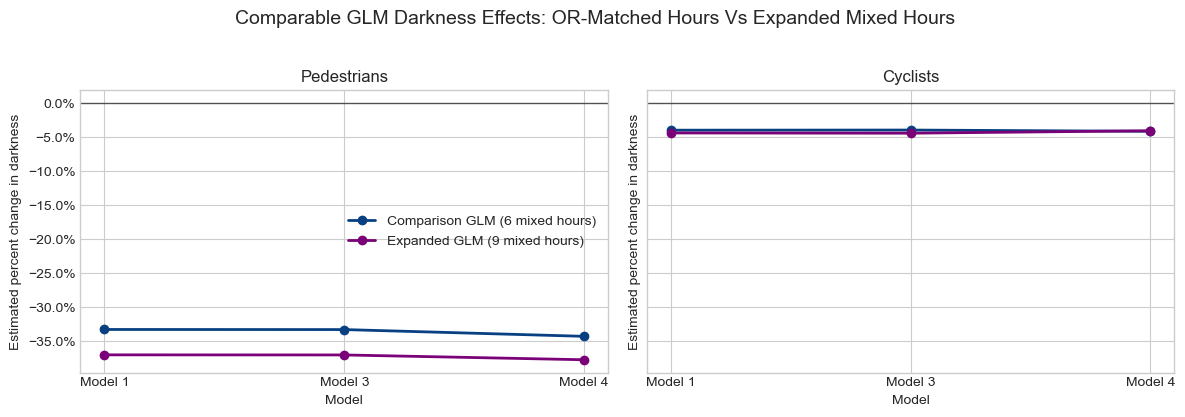

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
model_order = ['Model 1', 'Model 3', 'Model 4']
sample_order = ['Comparison GLM (6 mixed hours)', 'Expanded GLM (9 mixed hours)']
colors = {
    'Comparison GLM (6 mixed hours)': '#084081',
    'Expanded GLM (9 mixed hours)': '#7a0177',
}

for ax, outcome_label in zip(axes, ['Pedestrians', 'Cyclists']):
    sub = main_glm_compare[main_glm_compare['outcome_label'] == outcome_label].copy()
    ax.axhline(0, color='black', linewidth=1, alpha=0.6)
    for sample_name in sample_order:
        sample_sub = sub[sub['sample'] == sample_name].copy()
        sample_sub['x'] = [model_order.index(m) for m in sample_sub['model']]
        ax.plot(
            sample_sub['x'],
            sample_sub['dark_percent_change'],
            marker='o',
            linewidth=2,
            color=colors[sample_name],
            label=sample_name,
        )
    ax.set_xticks(range(len(model_order)))
    ax.set_xticklabels(model_order)
    ax.yaxis.set_major_formatter(PercentFormatter())
    ax.set_title(outcome_label)
    ax.set_xlabel('Model')
    ax.set_ylabel('Estimated percent change in darkness')

axes[0].legend(loc='best')
fig.suptitle('Comparable GLM Darkness Effects: OR-Matched Hours Vs Expanded Mixed Hours', y=1.03, fontsize=14)
plt.tight_layout()
plt.show()


## Figure Interpretation

This figure is the cleanest direct comparison between the **OR-matched GLM sample** and the **expanded mixed-hours GLM sample**.

Two takeaways matter most.

- **Pedestrians are stable across samples and model variants.** The darkness effect is strongly negative in both samples, and adding the extra mixed hours makes it slightly stronger rather than reversing or weakening it.
- **Cyclists are stable in a different way.** The pooled cyclist effect stays close to zero in both samples. That means the weak cyclist headline is not caused by having used too few mixed hours in the original six-hour comparison model.

So the figure is doing two jobs at once:

- it shows that the OR-comparable GLM result is not being driven by an unusually narrow hour set
- it shows that adding more mixed-hour data sharpens the pedestrian story more than the cyclist story


## Key Takeaways

### What the comparison shows

The OR results, the six-hour GLM, and the nine-hour GLM all support the same broad conclusion:

- **darkness has a much clearer effect on walking than on cycling**

That agreement matters because the two methods are not identical. The OR analysis is a matched case-control design built around selected control hours, while the GLM is a time-series count model with weather, calendar structure, lag terms, and sensor fixed effects. When two methods with different assumptions still point in the same direction, the conclusion is more credible.

### Why the methods do not give the same numbers

The OR plot and the GLM tables should not be expected to line up numerically.

- The **OR** is a relative odds-style comparison between mixed case hours and chosen control hours.
- The **GLM** is an adjusted percent change in counts attributed to darkness within the model.

So the right question is not “why isn’t the OR equal to `-33%`?” The right question is whether the methods agree about:

- which mode is more affected
- which parts of the day show the strongest contrast
- whether the darkness effect still survives once we add stronger controls

On those questions, they are largely consistent.

### What makes the pedestrian result convincing

The pedestrian story is strong in three different ways.

- In the **OR analysis**, pedestrian case-hour ORs are above `1` at all six case hours and are especially large at `05:00` and `06:00`.
- In the **six-hour GLM**, pedestrians are about `-33%` in the main pooled model.
- In the **expanded nine-hour GLM**, that effect becomes slightly stronger, around `-37%`.

That pattern makes substantive sense. Walking appears to be most affected exactly when darkness overlaps with daily utility travel, especially the morning and evening transition periods. The expanded sample strengthens the result rather than undermining it, which is what you would hope to see if the finding is real rather than fragile.

### What makes the cyclist result different

Cyclists show a weaker pooled darkness effect throughout.

- The OR signal is strongest at `06:00`, but it is much closer to `1` in the evening hours.
- The pooled GLM effect stays around `-4%` in both the six-hour and nine-hour samples.

That also makes sense. It suggests the cyclist story is not a simple city-wide average darkness penalty of the same kind seen for walking. Instead, the cyclist result is weaker in pooled models and likely depends more on where and when the trips happen. That is consistent with the separate heterogeneity findings in the main darkness notebook.

### What changed when more mixed hours were added

Adding `4`, `7`, and `21` did two useful things.

- It increased the amount of mixed-hour data substantially.
- It tested whether the six-hour comparison model was overly narrow.

The practical outcome is reassuring:

- the **pedestrian result gets slightly stronger**
- the **cyclist result barely changes**

So the expanded model improves coverage without contaminating the main OR comparison. It works best as a sensitivity analysis rather than a replacement for the OR-matched GLM.


## Reporting And Policy Use

A clear way to use this notebook in the report is:

1. start with the pooled OR results to show the original matched-hour design
2. use the **six-hour GLM** as the direct time-series comparison on the same hour set
3. use the **nine-hour GLM** as a robustness check showing what happens when all mixed hours are included

The strongest substantive message is:

- **walking shows a clear and robust darkness penalty across methods**
- **cycling shows a weaker pooled result, even after the sample is expanded**

In policy terms, that supports a stronger city-wide claim for walking than for cycling. The comparison suggests that improving the usability of walking routes during dark commuter-transition hours is the clearest evidence-backed action. For cycling, the comparison notebook reinforces the idea that pooled city-wide effects are limited, so the most useful next step is targeted place-based analysis rather than one blanket conclusion.
